# 1. Import and Hardware Setup

In [19]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader, random_split
from PIL import Image
import os
import glob
import random
import matplotlib.pyplot as plt
import numpy as np
!pip install tqdm kagglehub -q
import kagglehub
from tqdm.auto import tqdm

# Set device to GPU, MPS, or CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


# 2. Hyperparameter

In [20]:
BATCH_SIZE = 128
# CelebA-HQ native resolution is 256x256.
# We keep 128x128 to match the encoder channel stack (5 stride-2 layers = 128/32 = 4x4).
# Set to 256 if you have the GPU memory and want full resolution.
IMG_SIZE = 128
IN_CHANNELS = 3

LR = 1e-4
EPOCHS = 100
SEED = 42

# Global latent dimension (used for the bottom-level z_0 at 4x4).
LATENT_DIM = 256
ENCODER_CHANNELS = [32, 64, 128, 256, 512]

# Hierarchical latent channel widths at each scale (bottom -> top resolution).
# z_0 at 4x4   (global structure: pose, identity)
# z_1 at 8x8   (mid-level: expression, hair shape)
# z_2 at 16x16 (fine detail: skin texture, lighting)
HIER_LATENT_DIMS = [128, 64, 32]

# Dedicated test set size reserved exclusively for final evaluation
TEST_SAMPLES = 16

# Beta-VAE hyperparameter: scales the KL divergence term.
# beta = 1  ->  standard VAE.
# beta > 1  ->  stronger disentanglement pressure (Beta-VAE).
# For face datasets Higgins et al. recommend beta in [4, 10].
BETA = 4

# Train / validation split ratio
VAL_RATIO = 0.1

# 3. Dataset Download (CelebA-HQ 256 via kagglehub)

In [21]:
# Download CelebA-HQ 256 dataset via kagglehub.
# The dataset contains ~30 000 high-quality face images at 256x256 resolution.
# kagglehub caches the download so re-running this cell is fast.
DATASET_PATH = kagglehub.dataset_download("denislukovnikov/celebahq256-images-only")
print(f"Dataset downloaded to: {DATASET_PATH}")

# Inspect the folder structure to find the images
for root, dirs, files in os.walk(DATASET_PATH):
    level = root.replace(DATASET_PATH, '').count(os.sep)
    indent = '  ' * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 2:
        sub_indent = '  ' * (level + 1)
        for f in files[:5]:  # show first 5 files per dir
            print(f'{sub_indent}{f}')
        if len(files) > 5:
            print(f'{sub_indent}... ({len(files)} total)')

Dataset downloaded to: /kaggle/input/datasets/denislukovnikov/celebahq256-images-only
celebahq256-images-only/
  celebahq256_imgs/
    valid/
    train/


# 4. Data Preparation

In [22]:
def set_seed(seed: int = 42):
    """Set all random seeds for reproducibility."""
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    try:
        torch.use_deterministic_algorithms(True, warn_only=True)
    except Exception:
        pass

def seed_worker(worker_id):
    """Seed DataLoader workers for reproducibility."""
    worker_seed = SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)

In [23]:
class FlatImageDataset(Dataset):
    """
    A simple dataset that loads all images from a flat directory (no class sub-folders).

    CelebA-HQ stores images directly in one folder, so torchvision.datasets.ImageFolder
    cannot be used without wrapping.  This class scans for common image extensions,
    sorts the file list deterministically, and applies an optional transform.
    """

    EXTENSIONS = ('.jpg', '.jpeg', '.png', '.webp', '.bmp')

    def __init__(self, root: str, transform=None):
        self.root = root
        self.transform = transform
        # Recursively collect all image paths
        self.paths = sorted([
            p for p in glob.glob(os.path.join(root, '**', '*'), recursive=True)
            if p.lower().endswith(self.EXTENSIONS)
        ])
        if not self.paths:
            raise FileNotFoundError(
                f'No images found under {root!r}. '
                f'Supported extensions: {self.EXTENSIONS}'
            )
        print(f"FlatImageDataset: found {len(self.paths)} images in {root!r}")

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img

In [24]:
train_transform = transforms.Compose([
    # Slight upscale then random crop to augment spatial variation
    transforms.Resize(IMG_SIZE + 20),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    # Mild colour jitter — faces are sensitive to colour shifts
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.02),
    transforms.ToTensor(),
])

val_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE + 20),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
])

set_seed(SEED)
train_generator = torch.Generator().manual_seed(SEED)
eval_generator  = torch.Generator().manual_seed(SEED)

# Build dataset views over the image root.
full_train_dataset = FlatImageDataset(DATASET_PATH, transform=train_transform)
full_val_dataset   = FlatImageDataset(DATASET_PATH, transform=val_transform)

n_total = len(full_train_dataset)
n_test  = TEST_SAMPLES
n_val   = max(1, int((n_total - n_test) * VAL_RATIO))
n_train = n_total - n_val - n_test

# Compute deterministic split indices (train, validation, held-out test)
all_indices = list(range(n_total))
rng = random.Random(SEED)
rng.shuffle(all_indices)

train_indices = all_indices[:n_train]
val_indices   = all_indices[n_train:n_train + n_val]
test_indices  = all_indices[n_train + n_val:]

from torch.utils.data import Subset
train_subset = Subset(full_train_dataset, train_indices)
val_subset   = Subset(full_val_dataset,   val_indices)
test_subset  = Subset(full_val_dataset,   test_indices)  # Held-out test set

print(f"Train samples: {len(train_subset):,}  |  Val samples: {len(val_subset):,}  |  Test samples: {len(test_subset):,}")


FlatImageDataset: found 30000 images in '/kaggle/input/datasets/denislukovnikov/celebahq256-images-only'
FlatImageDataset: found 30000 images in '/kaggle/input/datasets/denislukovnikov/celebahq256-images-only'
Train samples: 26,986  |  Val samples: 2,998  |  Test samples: 16


In [25]:
train_loader = DataLoader(
    train_subset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    pin_memory=True,
    num_workers=4,
    persistent_workers=True,
    prefetch_factor=4,
    worker_init_fn=seed_worker,
    generator=train_generator,
)

val_loader = DataLoader(
    val_subset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=True,
    num_workers=4,
    persistent_workers=True,
    prefetch_factor=4,
    worker_init_fn=seed_worker,
    generator=eval_generator,
)

test_loader = DataLoader(
    test_subset,
    batch_size=TEST_SAMPLES,
    shuffle=False,
    pin_memory=True,
    num_workers=2,
    persistent_workers=True,
    prefetch_factor=2,
    worker_init_fn=seed_worker,
    generator=eval_generator,
)

print(f"Train batches: {len(train_loader)}  |  Val batches: {len(val_loader)}  |  Test batches: {len(test_loader)}")


Train batches: 211  |  Val batches: 24  |  Test batches: 1


# 5. Model Architecture

## Hierarchical Beta-VAE (Pure Latent Bottleneck)

**Key Architectural Principles**:

1. **Residual Blocks (Encoder & Decoder)**: Each encoder and decoder stage
   uses a 2-conv residual block with identity shortcuts (`ResBlock` / `ResBlockUp`).
   `AvgPool2d` is used for smooth downsampling; `Upsample` + `Conv3x3` prevents
   checkerboard artifacts.

2. **Hierarchical Latent Variables ($z_0, z_1, z_2$)**: Information flows strictly
   through 3 stochastic latent scales:
   - **$z_0$ at 4×4** (1D vector, 128 channels): Global structure (pose, face shape, identity).
   - **$z_1$ at 8×8** (Spatial, 64 channels): Mid-level features (expression, hair shape).
   - **$z_2$ at 16×16** (Spatial, 32 channels): Fine details (skin texture, lighting).

3. **No Direct Encoder-to-Decoder Skip-Connections**:
   Direct U-Net skips were **removed** to prevent posterior collapse (where
   the decoder bypasses $z$ by copying encoder features directly).
   All information **must** pass through the stochastic latent bottleneck $z$,
   ensuring excellent disentanglement and sharp sample generation.


In [26]:
# ---------------------------------------------------------------------------
# Building Blocks
# ---------------------------------------------------------------------------

class ResBlock(nn.Module):
    """Residual block for the encoder.

    Structure:
        x -> Conv3x3 -> BN -> LeakyReLU -> Conv3x3 -> BN -> (+x) -> LeakyReLU
        If in_channels != out_channels, a 1x1 conv adapts the shortcut.
    """

    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_channels)
        self.act   = nn.LeakyReLU(0.2, inplace=True)

        if in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, bias=False),
                nn.BatchNorm2d(out_channels),
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        identity = self.shortcut(x)
        out = self.act(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return self.act(out + identity)


class ResBlockUp(nn.Module):
    """Residual block for the decoder with Upsample + Conv (no ConvTranspose).

    Structure:
        x -> Upsample(2x) -> Conv3x3 -> BN -> LeakyReLU -> Conv3x3 -> BN -> (+x_up) -> LeakyReLU
        Shortcut is upsampled with nearest-neighbour + 1x1 conv.
    """

    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.up    = nn.Upsample(scale_factor=2, mode="nearest")
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_channels)
        self.act   = nn.LeakyReLU(0.2, inplace=True)

        self.shortcut = nn.Sequential(
            nn.Upsample(scale_factor=2, mode="nearest"),
            nn.Conv2d(in_channels, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        identity = self.shortcut(x)
        out = self.act(self.bn1(self.conv1(self.up(x))))
        out = self.bn2(self.conv2(out))
        return self.act(out + identity)


# ---------------------------------------------------------------------------
# Hierarchical Beta-VAE (Pure Stochastic Latent Bottleneck)
# ---------------------------------------------------------------------------

class HierarchicalBetaVAE(nn.Module):
    """Beta-VAE with Residual Blocks and Hierarchical Latent Variables.

    All information MUST flow through the stochastic latent variables z.
    No deterministic encoder-to-decoder skip-connections exist, ensuring
    that the latent space learns meaningful disentangled representations
    and generation z ~ N(0, I) produces clean, sharp images.

    Hierarchical Latent Structure:
        - z_0: 4x4 (128 channels, 1D bottleneck) -> Global structure & pose
        - z_1: 8x8 (64 channels, spatial) -> Mid-level features & expressions
        - z_2: 16x16 (32 channels, spatial) -> High-resolution detail & lighting

    Forward API:
        forward(x) -> (reconstruction, list_of_mus, list_of_logvars)
        encode(x)  -> (list_of_mus, list_of_logvars)
        decode(zs) -> reconstruction
    """

    def __init__(
        self,
        in_channels: int,
        img_size: int,
        encoder_channels: list,
        hier_latent_dims: list,
    ):
        super().__init__()
        num_levels = len(encoder_channels)
        self.num_levels = num_levels
        self.encoder_channels = encoder_channels
        self.hier_latent_dims = hier_latent_dims

        # Feature-map spatial size after all downsamplings
        self.final_h = img_size // (2 ** num_levels)
        self.final_w = img_size // (2 ** num_levels)
        assert self.final_h >= 1 and self.final_w >= 1, (
            f"Too many downsamplings: {num_levels} levels on {img_size}px input"
            f" -> {self.final_h}x{self.final_w} feature map."
        )

        # ---- Encoder: ResBlock + AvgPool at each level ----
        self.encoder_blocks = nn.ModuleList()
        self.encoder_pools  = nn.ModuleList()
        curr_ch = in_channels
        for out_ch in encoder_channels:
            self.encoder_blocks.append(ResBlock(curr_ch, out_ch))
            self.encoder_pools.append(nn.AvgPool2d(2))
            curr_ch = out_ch

        # ---- Hierarchical latent heads ----
        self.hier_mu     = nn.ModuleList()
        self.hier_logvar = nn.ModuleList()
        self.hier_proj   = nn.ModuleList()

        # Level 0 (bottom, 4x4): flatten bottleneck
        bottom_ch = encoder_channels[-1]
        flat_size = bottom_ch * self.final_h * self.final_w
        self.hier_mu.append(nn.Linear(flat_size, hier_latent_dims[0]))
        self.hier_logvar.append(nn.Linear(flat_size, hier_latent_dims[0]))
        self.hier_proj.append(
            nn.Sequential(
                nn.Linear(hier_latent_dims[0], flat_size),
                nn.LeakyReLU(0.2, inplace=True),
            )
        )

        # Level 1 (8x8): conv head on encoder features from level [-2]
        dec_channels = list(reversed(encoder_channels))  # [512, 256, 128, 64, 32]
        lvl1_enc_ch = encoder_channels[-2]
        lvl1_dec_ch = dec_channels[1]
        self.hier_mu.append(nn.Conv2d(lvl1_enc_ch, hier_latent_dims[1], 1, bias=True))
        self.hier_logvar.append(nn.Conv2d(lvl1_enc_ch, hier_latent_dims[1], 1, bias=True))
        self.hier_proj.append(nn.Conv2d(hier_latent_dims[1], lvl1_dec_ch, 1, bias=False))

        # Level 2 (16x16): conv head on encoder features from level [-3]
        lvl2_enc_ch = encoder_channels[-3]
        lvl2_dec_ch = dec_channels[2]
        self.hier_mu.append(nn.Conv2d(lvl2_enc_ch, hier_latent_dims[2], 1, bias=True))
        self.hier_logvar.append(nn.Conv2d(lvl2_enc_ch, hier_latent_dims[2], 1, bias=True))
        self.hier_proj.append(nn.Conv2d(hier_latent_dims[2], lvl2_dec_ch, 1, bias=False))

        # ---- Decoder: ResBlockUp stages ----
        self.decoder_blocks = nn.ModuleList()
        for i in range(len(dec_channels) - 1):
            self.decoder_blocks.append(ResBlockUp(dec_channels[i], dec_channels[i + 1]))
        self.decoder_blocks.append(ResBlockUp(dec_channels[-1], dec_channels[-1]))

        # Final output head
        self.output_head = nn.Sequential(
            nn.Conv2d(dec_channels[-1], in_channels, 3, padding=1),
            nn.Sigmoid(),
        )

    # ------------------------------------------------------------------
    def reparameterize(self, mu, logvar):
        """Sample z = mu + std * eps,  eps ~ N(0,1)  (reparameterisation trick)."""
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + std * eps

    # ------------------------------------------------------------------
    def encode(self, x):
        """Encode input x through the residual encoder.

        Returns:
            all_mus:     list of mu tensors at each hierarchical level
            all_logvars: list of logvar tensors at each hierarchical level
        """
        features = {}
        h = x
        for i, (block, pool) in enumerate(zip(self.encoder_blocks, self.encoder_pools)):
            h = block(h)
            features[i] = h
            h = pool(h)

        all_mus = []
        all_logvars = []

        # Level 0 (bottom, 4x4)
        h_flat = h.flatten(1)
        mu_0 = self.hier_mu[0](h_flat)
        logvar_0 = torch.clamp(self.hier_logvar[0](h_flat), -20.0, 20.0)
        all_mus.append(mu_0)
        all_logvars.append(logvar_0)

        # Level 1 (8x8)
        enc_feat_1 = features[self.num_levels - 2]
        enc_feat_1_pooled = F.avg_pool2d(enc_feat_1, 2)
        mu_1 = self.hier_mu[1](enc_feat_1_pooled)
        logvar_1 = torch.clamp(self.hier_logvar[1](enc_feat_1_pooled), -20.0, 20.0)
        all_mus.append(mu_1)
        all_logvars.append(logvar_1)

        # Level 2 (16x16)
        enc_feat_2 = features[self.num_levels - 3]
        enc_feat_2_pooled = F.avg_pool2d(enc_feat_2, 2)
        mu_2 = self.hier_mu[2](enc_feat_2_pooled)
        logvar_2 = torch.clamp(self.hier_logvar[2](enc_feat_2_pooled), -20.0, 20.0)
        all_mus.append(mu_2)
        all_logvars.append(logvar_2)

        return all_mus, all_logvars

    # ------------------------------------------------------------------
    def decode(self, zs):
        """Decode hierarchical latent samples to pixel space.

        Args:
            zs: list of z tensors [z_0, z_1, z_2].
                z_0 is 1D (B, dim), z_1 and z_2 are spatial (B, C, H, W).

        Returns:
            Reconstructed image tensor (B, C, H, W) in [0, 1].
        """
        # Start from z_0: project to spatial feature map (512 @ 4x4)
        h = self.hier_proj[0](zs[0])
        h = h.view(-1, self.encoder_channels[-1], self.final_h, self.final_w)

        # Stage 0: 512@4x4 -> 256@8x8
        h = self.decoder_blocks[0](h)

        # Inject z_1 at 8x8 (additive, 256ch)
        z1_proj = self.hier_proj[1](zs[1])
        h = h + z1_proj

        # Stage 1: 256@8x8 -> 128@16x16
        h = self.decoder_blocks[1](h)

        # Inject z_2 at 16x16 (additive, 128ch)
        z2_proj = self.hier_proj[2](zs[2])
        h = h + z2_proj

        # Stage 2: 128@16x16 -> 64@32x32
        h = self.decoder_blocks[2](h)

        # Stage 3: 64@32x32 -> 32@64x64
        h = self.decoder_blocks[3](h)

        # Stage 4: 32@64x64 -> 32@128x128
        h = self.decoder_blocks[4](h)

        return self.output_head(h)

    # ------------------------------------------------------------------
    def forward(self, x):
        """Full forward pass: encode -> reparameterise -> decode.

        Returns:
            reconstructed: (B, C, H, W) reconstructed image
            all_mus:       list of mu tensors at each hierarchical level
            all_logvars:   list of logvar tensors at each hierarchical level
        """
        all_mus, all_logvars = self.encode(x)
        zs = [
            self.reparameterize(mu, logvar)
            for mu, logvar in zip(all_mus, all_logvars)
        ]
        reconstructed = self.decode(zs)
        return reconstructed, all_mus, all_logvars


In [27]:
model = HierarchicalBetaVAE(
    in_channels=IN_CHANNELS,
    img_size=IMG_SIZE,
    encoder_channels=ENCODER_CHANNELS,
    hier_latent_dims=HIER_LATENT_DIMS,
).to(device)

n_params = sum(p.numel() for p in model.parameters()) / 1e6
print(f"Total parameters: {n_params:.2f}M")
print(f"Feature map after encoder: {model.final_h}x{model.final_w}")
print(f"Hierarchical latent dims: {HIER_LATENT_DIMS}")

# Quick shape sanity check
with torch.no_grad():
    dummy = torch.randn(2, IN_CHANNELS, IMG_SIZE, IMG_SIZE, device=device)
    recon, mus, logvars = model(dummy)
    print(f"\nShape check:")
    print(f"  Input:          {dummy.shape}")
    print(f"  Reconstruction: {recon.shape}")
    for i, (m, lv) in enumerate(zip(mus, logvars)):
        print(f"  z_{i} mu/logvar:  {m.shape}")
    del dummy, recon, mus, logvars


Total parameters: 10.65M
Feature map after encoder: 4x4
Hierarchical latent dims: [128, 64, 32]

Shape check:
  Input:          torch.Size([2, 3, 128, 128])
  Reconstruction: torch.Size([2, 3, 128, 128])
  z_0 mu/logvar:  torch.Size([2, 128])
  z_1 mu/logvar:  torch.Size([2, 64, 8, 8])
  z_2 mu/logvar:  torch.Size([2, 32, 16, 16])


# 6. Loss Function

In [28]:
def beta_vae_loss(reconstructed, original, all_mus, all_logvars, beta=1.0):
    """Compute the Beta-VAE loss with hierarchical KL divergence.

    The KL term sums over all hierarchical latent levels.
    Each level can have different tensor shapes:
      - 1D latents (B, D):         standard KL formula
      - Spatial latents (B, C, H, W): KL summed over spatial + channel dims

    Args:
        reconstructed: Decoder output (B, C, H, W) in [0, 1].
        original:      Target image (B, C, H, W).
        all_mus:       List of mu tensors at each hierarchical level.
        all_logvars:   List of logvar tensors at each hierarchical level.
        beta:          Scaling factor for the total KL divergence.

    Returns:
        total_loss, recon_loss, kl_loss  (all scalar, per-sample averaged)
    """
    batch_size = original.size(0)

    # Reconstruction loss: MSE summed over pixels, averaged over batch
    recon_loss = (
        F.mse_loss(reconstructed, original, reduction="sum") / batch_size
    )

    # Hierarchical KL: sum KL from each level, then average over batch
    kl_loss = torch.tensor(0.0, device=original.device)
    for mu, logvar in zip(all_mus, all_logvars):
        # KL = -0.5 * sum(1 + logvar - mu^2 - exp(logvar))
        # Works for both 1D (B, D) and spatial (B, C, H, W) tensors
        kl_level = -0.5 * torch.sum(
            1.0 + logvar - mu.pow(2) - logvar.exp()
        ) / batch_size
        kl_loss = kl_loss + kl_level

    total_loss = recon_loss + beta * kl_loss
    return total_loss, recon_loss, kl_loss


# 7. Train

In [29]:
class EarlyStopping:
    """Halt training when validation loss stops improving."""
    def __init__(self, patience=10, delta=0.0, verbose=False,
                 save_path="best_checkpoint.pth"):
        self.patience   = patience
        self.delta      = delta
        self.verbose    = verbose
        self.save_path  = save_path
        self.early_stop = False
        self.counter    = 0
        self.best_loss  = None

    def __call__(self, model, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
            self._save(model)
        elif val_loss >= self.best_loss - self.delta:
            self.counter += 1
            print(f"EarlyStopping: {self.counter}/{self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.counter   = 0
            self.best_loss = val_loss
            self._save(model)

    def _save(self, model):
        if self.verbose:
            print("Saving best checkpoint ...")
        sd = model.module.state_dict() if hasattr(model, 'module') else model.state_dict()
        torch.save(sd, self.save_path)

In [30]:
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-5)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)
scaler    = torch.amp.GradScaler(device=device)

In [31]:
def train_epoch(model, loader, optimizer, scaler, beta):
    """Train the Hierarchical Beta-VAE for one epoch.

    Returns (total, recon, kl) averaged per sample.
    """
    model.train()
    total_loss = total_recon = total_kl = 0.0
    loop = tqdm(loader, desc="Training", leave=False)

    for images in loop:
        images = images.to(device)
        optimizer.zero_grad(set_to_none=True)

        with torch.autocast(device_type=device.type):
            reconstructed, all_mus, all_logvars = model(images)
            loss, recon_loss, kl_loss = beta_vae_loss(
                reconstructed, images, all_mus, all_logvars, beta
            )

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        bs = images.size(0)
        total_loss  += loss.detach()       * bs
        total_recon += recon_loss.detach() * bs
        total_kl    += kl_loss.detach()    * bs

    n = len(loader.dataset)
    return total_loss.item() / n, total_recon.item() / n, total_kl.item() / n


def validate_epoch(model, loader, beta):
    """Evaluate the Hierarchical Beta-VAE for one epoch.

    Returns (total, recon, kl) averaged per sample.
    """
    model.eval()
    total_loss = total_recon = total_kl = 0.0
    loop = tqdm(loader, desc="Validation", leave=False)

    with torch.no_grad():
        for images in loop:
            images = images.to(device)
            reconstructed, all_mus, all_logvars = model(images)
            loss, recon_loss, kl_loss = beta_vae_loss(
                reconstructed, images, all_mus, all_logvars, beta
            )
            bs = images.size(0)
            total_loss  += loss.detach()       * bs
            total_recon += recon_loss.detach() * bs
            total_kl    += kl_loss.detach()    * bs

    n = len(loader.dataset)
    return total_loss.item() / n, total_recon.item() / n, total_kl.item() / n


In [32]:
early_stopping = EarlyStopping(patience=10, save_path="best_hier_beta_vae_celeba.pth")
train_losses       = []
val_losses         = []
train_recon_losses = []
val_recon_losses   = []
train_kl_losses    = []
val_kl_losses      = []

for epoch in range(EPOCHS):

    beta = min(BETA, BETA * (epoch +1) / 5)

    train_loss, train_recon, train_kl = train_epoch(
        model, train_loader, optimizer, scaler, beta
    )
    val_loss, val_recon, val_kl = validate_epoch(
        model, val_loader, BETA
    )
    scheduler.step()

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_recon_losses.append(train_recon)
    val_recon_losses.append(val_recon)
    train_kl_losses.append(train_kl)
    val_kl_losses.append(val_kl)

    print(
        f"Epoch {epoch+1}/{EPOCHS}: "
        f"Beta: {beta} | "
        f"Train Loss: {train_loss:.6f} (Recon: {train_recon:.6f}, KL: {train_kl:.3f}) | "
        f"Val Loss: {val_loss:.6f} (Recon: {val_recon:.6f}, KL: {val_kl:.3f})"
    )

    early_stopping(model, val_loss)
    if early_stopping.early_stop:
        print("Early stopping triggered.")
        break

# Load the best checkpoint for evaluation
model.load_state_dict(torch.load("best_hier_beta_vae_celeba.pth"))
print("Best model loaded.")


Training:   0%|          | 0/211 [00:00<?, ?it/s]

Validation:   0%|          | 0/24 [00:00<?, ?it/s]

Epoch 1/100: Beta: 0.8 | Train Loss: 1423.582747 (Recon: 990.667457, KL: 541.144) | Val Loss: 1726.218479 (Recon: 590.823674, KL: 283.849)


Training:   0%|          | 0/211 [00:00<?, ?it/s]

Validation:   0%|          | 0/24 [00:00<?, ?it/s]

...

Training:   0%|          | 0/211 [00:00<?, ?it/s]

Validation:   0%|          | 0/24 [00:00<?, ?it/s]

Epoch 70/100: Beta: 4 | Train Loss: 749.117468 (Recon: 511.157267, KL: 59.490) | Val Loss: 740.399433 (Recon: 505.916069, KL: 58.621)


Training:   0%|          | 0/211 [00:00<?, ?it/s]

KeyboardInterrupt: 

# 8. Result Visualization

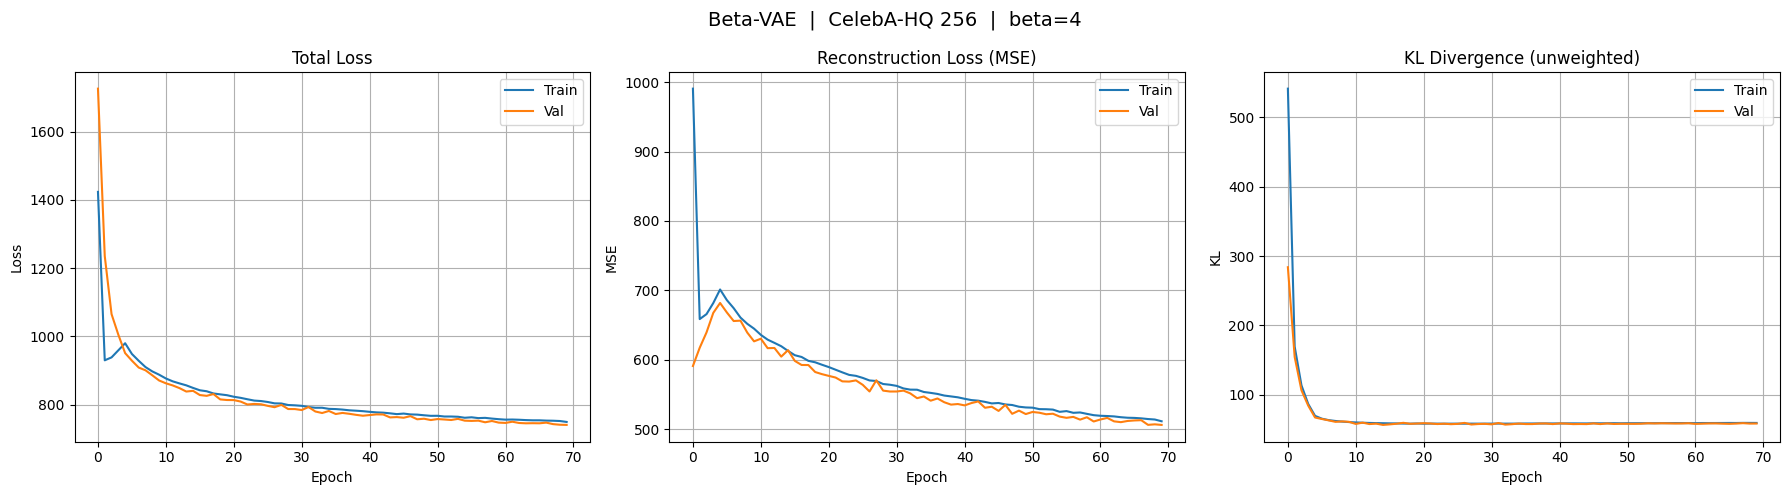

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(train_losses,       label='Train')
axes[0].plot(val_losses,         label='Val')
axes[0].set_title('Total Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(train_recon_losses, label='Train')
axes[1].plot(val_recon_losses,   label='Val')
axes[1].set_title('Reconstruction Loss (MSE)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MSE')
axes[1].legend(); axes[1].grid(True)

axes[2].plot(train_kl_losses,    label='Train')
axes[2].plot(val_kl_losses,      label='Val')
axes[2].set_title('KL Divergence (unweighted)')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('KL')
axes[2].legend(); axes[2].grid(True)

plt.suptitle(f'Beta-VAE  |  CelebA-HQ 256  |  beta={BETA}', fontsize=14)
plt.tight_layout()
plt.show()

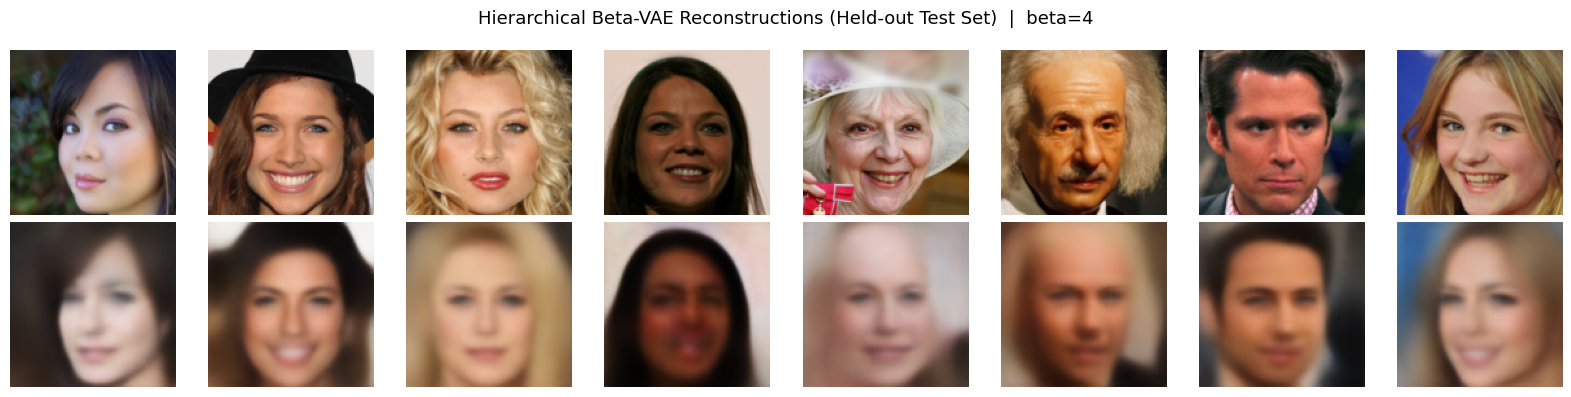

In [34]:
def show_reconstructions(model, loader=None, n=8):
    """Show n original CelebA faces alongside their reconstructions from the test set."""
    if loader is None:
        loader = test_loader
    model.eval()
    images = next(iter(loader))[:n].to(device)

    with torch.no_grad():
        reconstructed, _, _ = model(images)

    images        = images.cpu()
    reconstructed = reconstructed.cpu()

    fig, axes = plt.subplots(2, n, figsize=(n * 2, 4))
    for i in range(n):
        axes[0, i].imshow(images[i].permute(1, 2, 0).clamp(0, 1))
        axes[0, i].axis("off")
        axes[1, i].imshow(reconstructed[i].permute(1, 2, 0).clamp(0, 1))
        axes[1, i].axis("off")
    axes[0, 0].set_ylabel("Original",      fontsize=12)
    axes[1, 0].set_ylabel("Reconstructed",  fontsize=12)
    plt.suptitle(
        f"Hierarchical Beta-VAE Reconstructions (Held-out Test Set)  |  beta={BETA}",
        fontsize=13,
    )
    plt.tight_layout()
    plt.show()

show_reconstructions(model, test_loader)


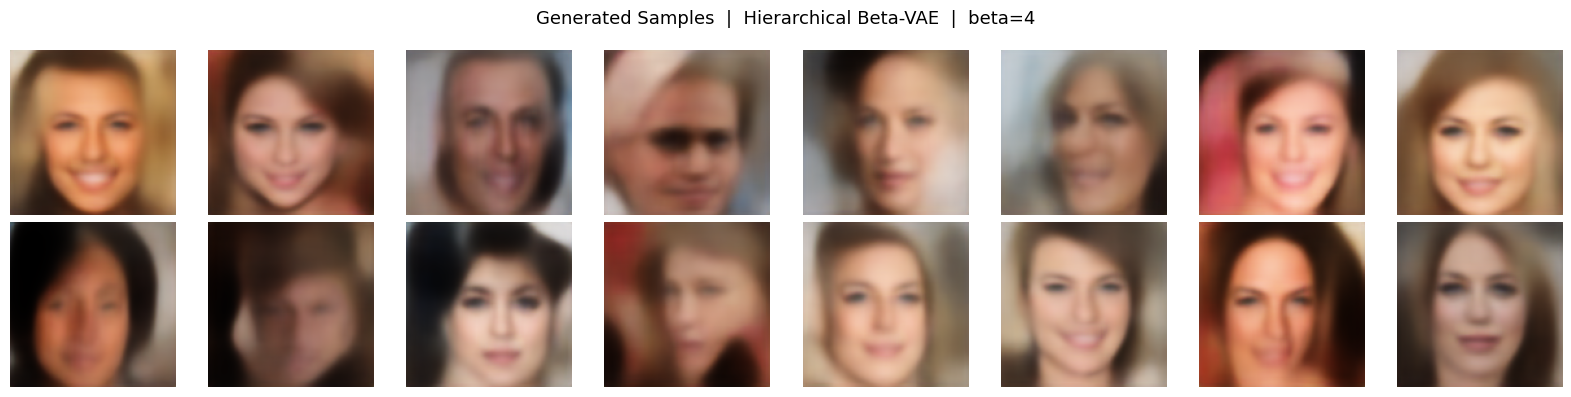

In [35]:
def generate_samples(model, n=16):
    """Sample z ~ N(0,I) at every hierarchical level and decode to generate new faces."""
    model.eval()
    with torch.no_grad():
        zs = []
        # z_0: 1D latent (B, hier_latent_dims[0])
        zs.append(torch.randn(n, HIER_LATENT_DIMS[0], device=device))

        # z_1: spatial latent at 8x8 (B, hier_latent_dims[1], 8, 8)
        spatial_h1 = IMG_SIZE // (2 ** (len(ENCODER_CHANNELS) - 1))  # = 8
        zs.append(
            torch.randn(n, HIER_LATENT_DIMS[1], spatial_h1, spatial_h1, device=device)
        )

        # z_2: spatial latent at 16x16 (B, hier_latent_dims[2], 16, 16)
        spatial_h2 = IMG_SIZE // (2 ** (len(ENCODER_CHANNELS) - 2))  # = 16
        zs.append(
            torch.randn(n, HIER_LATENT_DIMS[2], spatial_h2, spatial_h2, device=device)
        )

        samples = model.decode(zs).cpu()

    cols = 8
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2))
    axes = axes.flatten()
    for i, ax in enumerate(axes):
        if i < n:
            ax.imshow(samples[i].permute(1, 2, 0).clamp(0, 1))
        ax.axis("off")
    plt.suptitle(
        f"Generated Samples  |  Hierarchical Beta-VAE  |  beta={BETA}",
        fontsize=13,
    )
    plt.tight_layout()
    plt.show()

generate_samples(model)


# 9. Latent Space Traversal

Vary individual latent dimensions to inspect which facial attributes they encode.
With `beta > 1` (Beta-VAE) each dimension ideally controls a **single interpretable**
factor such as smile, pose, lighting, or hair colour.

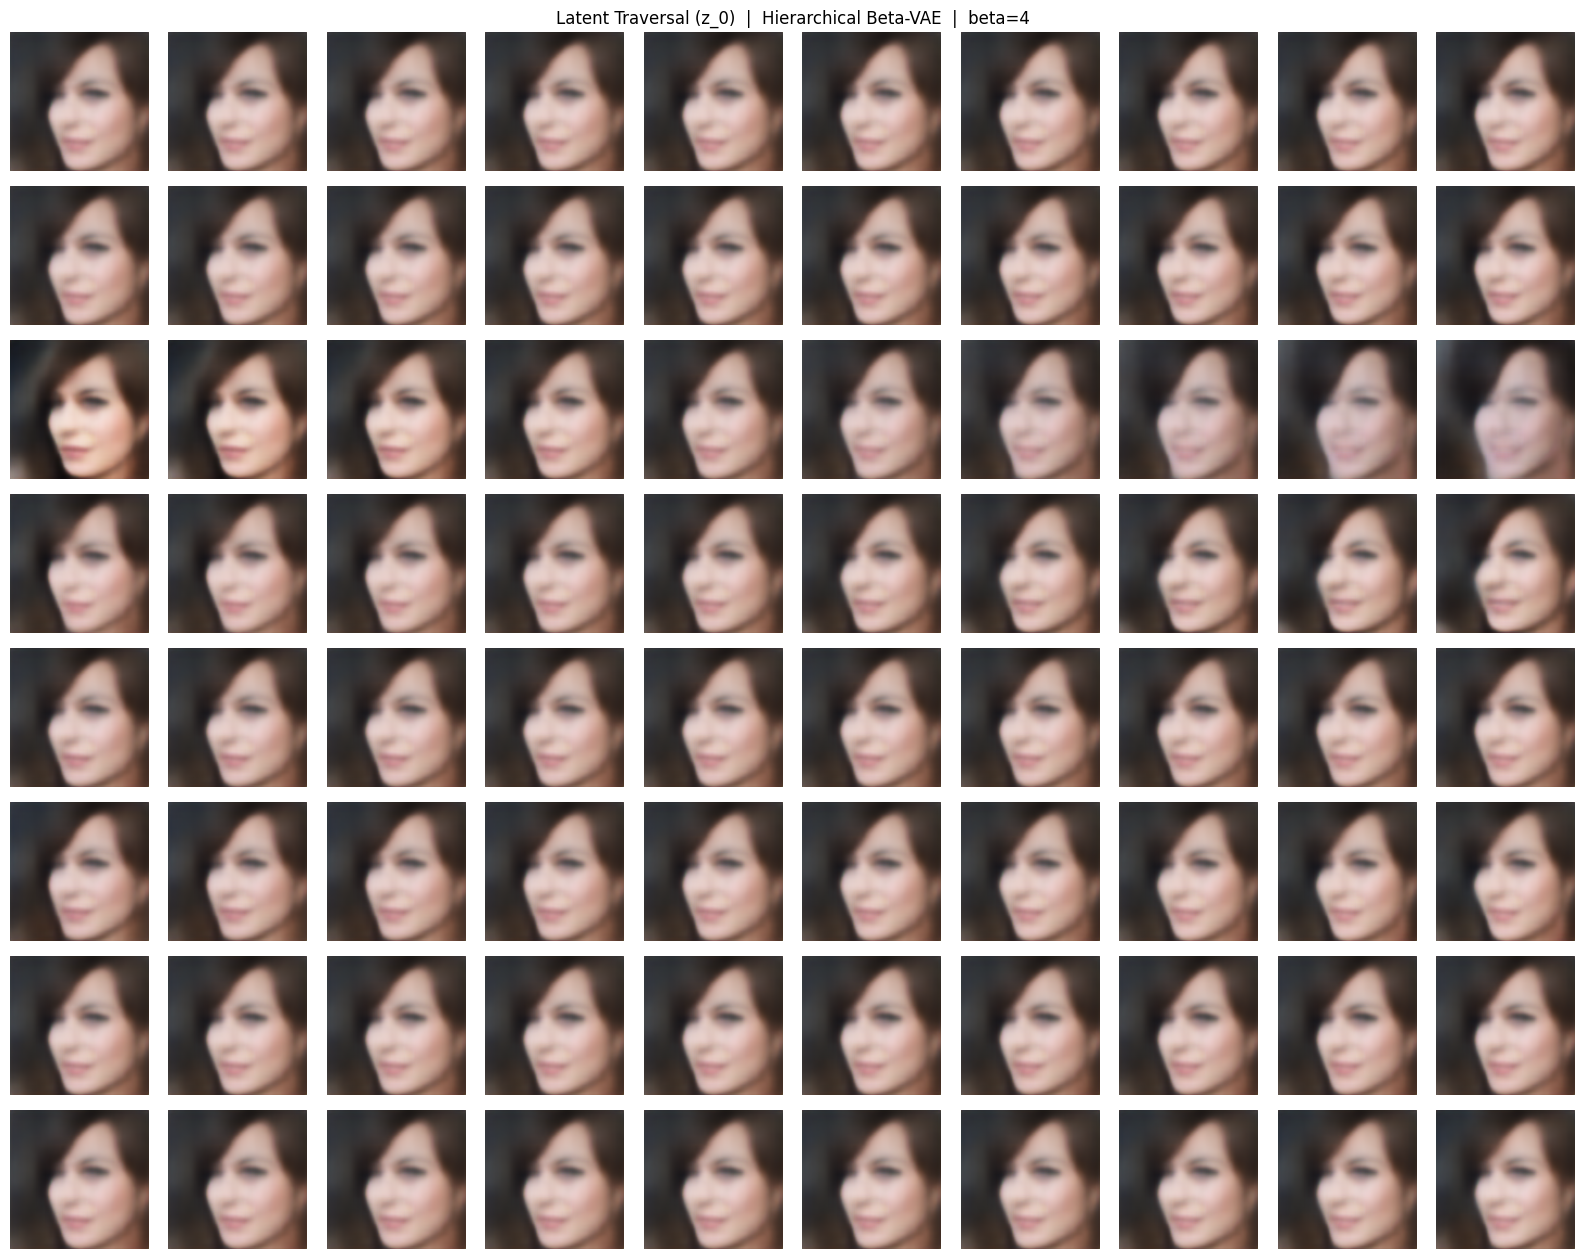

In [36]:
def latent_traversal(model, loader=None, dim_range=(-3, 3), n_steps=10, n_dims=8):
    """Vary individual dimensions of the bottom-level z_0 (global features).

    With beta > 1 each dimension of z_0 tends to encode a single
    interpretable attribute (pose, lighting, smile, hair colour).
    z_1 and z_2 are held at their encoded values for this traversal.
    """
    if loader is None:
        loader = test_loader
    model.eval()
    ref_img = next(iter(loader))[:1].to(device)

    with torch.no_grad():
        all_mus, all_logvars = model.encode(ref_img)
        zs_base = [
            model.reparameterize(mu, logvar)
            for mu, logvar in zip(all_mus, all_logvars)
        ]

    n_dims = min(n_dims, HIER_LATENT_DIMS[0])
    values = torch.linspace(dim_range[0], dim_range[1], n_steps)

    fig, axes = plt.subplots(n_dims, n_steps,
                             figsize=(n_steps * 1.6, n_dims * 1.6))
    for d in range(n_dims):
        for s, val in enumerate(values):
            zs = [z.clone() for z in zs_base]
            zs[0][0, d] = val
            with torch.no_grad():
                img = model.decode(zs).cpu().squeeze(0)
            axes[d, s].imshow(img.permute(1, 2, 0).clamp(0, 1))
            axes[d, s].axis("off")
        axes[d, 0].set_ylabel(f"z_0[{d}]", fontsize=9, rotation=0,
                              labelpad=35, va="center")

    plt.suptitle(
        f"Latent Traversal (z_0)  |  Hierarchical Beta-VAE  |  beta={BETA}",
        fontsize=12,
    )
    plt.tight_layout()
    plt.show()

latent_traversal(model, test_loader)
